# Visualisatie: Top 10 Landen met Meeste Bestellingen

Welkom in deze notebook! Hierin analyseren we e-commerce transacties uit het **Online Retail** databestand. 

In deze analyse doorlopen we de volgende stappen:
* **Pakketten installeren & laden:** Benodigde bibliotheken zoals `pandas` en `matplotlib` klaarzetten (en installeren via `piplite` voor browser-gebaseerde Jupyter environments zoals JupyterLite).
* **Data inlezen & opschonen:** Het Excel-bestand inladen en afkortingen van landnamen (zoals *EIRE* en *RSA*) corrigeren voor betere leesbaarheid.
* **Data-analyse:** De top 10 landen met het hoogste aantal bestellingen bepalen (met uitsluiting van 'Unspecified').
* **Visualisatie:** Een overzichtelijke staafgrafiek met duidelijke gegevenslabels maken om de verdeling per land inzichtelijk te presenteren.

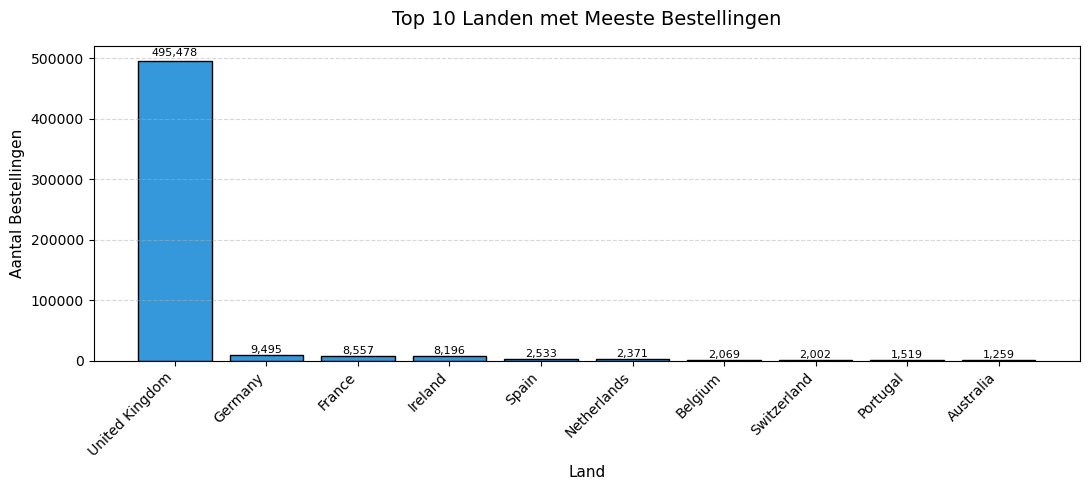

In [16]:
import piplite
await piplite.install(['openpyxl', 'matplotlib'])

import pandas as pd
import matplotlib.pyplot as plt


# 1. data inlezen
df = pd.read_excel('../data/Online Retail.xlsx')

# 2. Landnamen opschonen
country_mapping = {'EIRE': 'Ireland', 'RSA': 'South Africa', 'USA': 'United States'}
df['Country'] = df['Country'].replace(country_mapping)

# 3. Top 10 landen ophalen (zonder 'Unspecified')
top_10 = df['Country'].value_counts().drop('Unspecified', errors='ignore').head(10)

# 4. Bar chart maken
plt.figure(figsize=(11, 5))
bars = plt.bar(top_10.index, top_10.values, color='#3498db', edgecolor='black')

# Gegevenslabels boven de staven zetten
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.01), f'{yval:,}', ha='center', va='bottom', fontsize=8)

plt.title('Top 10 Landen met Meeste Bestellingen', fontsize=14, pad=15)
plt.xlabel('Land', fontsize=11)
plt.ylabel('Aantal Bestellingen', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()



In [17]:
#tabel printen
top_10


Country
United Kingdom    495478
Germany             9495
France              8557
Ireland             8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

### Geografische Visualisatie: Top 10 Landen

Met onderstaande code plotten we de **Top 10 landen** met de meeste bestellingen op een interactieve wereldkaart:

* **Folium:** Wordt geïnstalleerd en gebruikt om een dynamische kaart te genereren.
* **Coördinaten:** Elk land uit de top 10 is gekoppeld aan de exacte lengte- en breedtegraad.
* **Proportionele Cirkels:** De grootte van elke cirkel schaalt mee op basis van het aantal bestellingen (`top_10`), waardoor de geografische spreiding direct zichtbaar is.

In [23]:
import piplite
await piplite.install('folium')

import folium

# Coördinaten van de top 10 landen
coords = {
    'United Kingdom': [55.3781, -3.4360],
    'Germany': [51.1657, 10.4515],
    'France': [46.2276, 2.2137],
    'Ireland': [53.1424, -7.6921],
    'Spain': [40.4637, -3.7492],
    'Netherlands': [52.1326, 5.2913],
    'Belgium': [50.5039, 4.4699],
    'Switzerland': [46.8182, 8.2275],
    'Portugal': [39.3999, -8.2245],
    'Australia': [-25.2744, 133.7751]
}

# 1. Basiskaart aanmaken
m = folium.Map(location=[30, 0], zoom_start=2)

# 2. Cirkels plaatsen op basis van de top_10 variabelen uit je vorige cel
max_val = top_10.max()

for country, count in top_10.items():
    if country in coords:
        folium.CircleMarker(
            location=coords[country],
            radius=(count / max_val) * 20 + 5,  # Cirkelgrootte schaalt met het aantal bestellingen
            popup=f"<b>{country}</b><br>{count:,} bestellingen",
            color='#3498db',
            fill=True,
            fill_color='#3498db',
            fill_opacity=0.6
        ).add_to(m)

# 3. Kaart tonen
m